About Dataset
📝 Context & Overview Crude oil is one of the most critical macro-economic indicators in the global market. This dataset provides a comprehensive, continuous, and highly clean historical record of WTI (West Texas Intermediate) Crude Oil Futures (CL=F).

Spanning over two decades, this dataset is designed for data scientists, financial analysts, and researchers looking to perform time-series forecasting, algorithmic trading backtesting, or exploratory data analysis (EDA) on global energy shocks.

📊 Dataset Highlights Time Range: August 23, 2000, to Present.

Volume: 6,435 continuous trading days.

Cleanliness: 100% complete with zero missing values (6435 non-null entries).

Added Value: Includes pre-calculated Daily_Return_% and Intraday_Volatility to jumpstart your exploratory analysis.

Lightweight: Highly optimized formatting (~402 KB).

📖 Data Dictionary (Column Descriptions) Here is a step-by-step breakdown of the 8 features included in this dataset:

📅 Date (object): The specific trading date (Standardized format: YYYY-MM-DD).

🟢 Open (float64): The price of WTI crude oil at the opening of the trading day.

📈 High (float64): The highest price recorded during that specific trading session.

📉 Low (float64): The lowest price recorded during that specific trading session.

🔴 Close (float64): The final closing price of the trading day.

📊 Volume (int64): The total number of contracts traded during the session.

🧮 Daily_Return_% (float64): [Engineered Feature] The percentage change in the closing price compared to the previous trading day.

⚡ Intraday_Volatility (float64): [Engineered Feature] The absolute price difference between the daily High and Low (High - Low), representing daily market turbulence.

💡 Inspiration & Use Cases Not sure where to start? Here are a few ways you can utilize this data:

Time-Series Forecasting: Can you build an LSTM, ARIMA, or Prophet model to accurately predict the Close price for the next 7 days?

Economic Event Analysis: Correlate major global events (e.g., 2008 Financial Crisis, 2020 Pandemic) with spikes in Intraday_Volatility.

Algorithmic Trading Strategies: Use the Daily_Return_% to backtest momentum or mean-reversion trading algorithms.

🤝 Acknowledgements Data was extracted and formatted using the Yahoo Finance API (yfinance).

If you find this dataset useful for your research or notebooks, an upvote is highly appreciated!

In [1]:
import pandas as pd 
import numpy as np 
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
from datetime import datetime

c:\Users\Azog\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = kagglehub.dataset_download('meharshanali/all-time-crude-oil-stocks-data')

In [3]:
df = pd.read_csv(os.path.join(file_path, 'Crude_Oil.csv'))

In [4]:
df

,Date,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility
0,2000-08-23,31.950001,32.799999,31.950001,32.049999,79385,0.00,0.85
1,2000-08-24,31.900000,32.240002,31.400000,31.629999,72978,-1.31,0.84
2,2000-08-25,31.700001,32.099998,31.320000,32.049999,44601,1.33,0.78
3,2000-08-28,32.040001,32.919998,31.860001,32.869999,46770,2.56,1.06
4,2000-08-29,32.820000,33.029999,32.560001,32.720001,49131,-0.46,0.47
...,...,...,...,...,...,...,...,...
6430,2026-04-06,112.959999,115.480003,108.889999,112.410004,271742,0.78,6.59
6431,2026-04-07,112.620003,117.629997,109.199997,112.949997,429331,0.48,8.43
6432,2026-04-08,108.739998,109.190002,91.050003,94.410004,599576,-16.41,18.14
6433,2026-04-09,96.779999,102.699997,95.250000,97.870003,427201,3.66,7.45


In [5]:
df.set_index('Date', inplace=True)

In [6]:
df

,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility
Date,,,,,,,
2000-08-23,31.950001,32.799999,31.950001,32.049999,79385,0.00,0.85
2000-08-24,31.900000,32.240002,31.400000,31.629999,72978,-1.31,0.84
2000-08-25,31.700001,32.099998,31.320000,32.049999,44601,1.33,0.78
2000-08-28,32.040001,32.919998,31.860001,32.869999,46770,2.56,1.06
2000-08-29,32.820000,33.029999,32.560001,32.720001,49131,-0.46,0.47
...,...,...,...,...,...,...,...
2026-04-06,112.959999,115.480003,108.889999,112.410004,271742,0.78,6.59
2026-04-07,112.620003,117.629997,109.199997,112.949997,429331,0.48,8.43
2026-04-08,108.739998,109.190002,91.050003,94.410004,599576,-16.41,18.14


In [7]:
df = df.round(4)

In [8]:
df

,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility
Date,,,,,,,
2000-08-23,31.95,32.80,31.95,32.05,79385,0.00,0.85
2000-08-24,31.90,32.24,31.40,31.63,72978,-1.31,0.84
2000-08-25,31.70,32.10,31.32,32.05,44601,1.33,0.78
2000-08-28,32.04,32.92,31.86,32.87,46770,2.56,1.06
2000-08-29,32.82,33.03,32.56,32.72,49131,-0.46,0.47
...,...,...,...,...,...,...,...
2026-04-06,112.96,115.48,108.89,112.41,271742,0.78,6.59
2026-04-07,112.62,117.63,109.20,112.95,429331,0.48,8.43
2026-04-08,108.74,109.19,91.05,94.41,599576,-16.41,18.14


Here are some additions to the chart:

1. I'm adding the 21, 55, and 99-period moving averages.
2. I've included the ADX indicator (which measures the strength of a market trend from 0 to 100), with periods of 14 and 22.
3. I've included the ATR indicator to understand the volatility of 21-period trades.

With these parameters, it's possible to understand and interpret the asset's direction, filtering out bad entry points, positions that would occasionally lead to stop-loss orders, or simply a bad direction driven by a short correction.

It's possible to analyze and interpret market volatility through technical indicators that measure how strong a reversal or trend might be.

In this way, entries could become more accurate and better filter the timeframe chart to minimize money loss.

An important concept about the financial market is that well-adjusted forecasting models will mostly have a low or moderate success rate, but well-applied filters serve to prevent bad entries or control money loss.

With the inclusion of these filters, the intention is to minimize drawdown, increase mathematical expectation, and leverage risk/reward by at least 1:2.5

In [9]:
df['sma21'] = df.Intraday_Volatility.rolling(window=21).mean()

In [10]:
df

,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility,sma21
Date,,,,,,,,
2000-08-23,31.95,32.80,31.95,32.05,79385,0.00,0.85,NaN
2000-08-24,31.90,32.24,31.40,31.63,72978,-1.31,0.84,NaN
2000-08-25,31.70,32.10,31.32,32.05,44601,1.33,0.78,NaN
2000-08-28,32.04,32.92,31.86,32.87,46770,2.56,1.06,NaN
2000-08-29,32.82,33.03,32.56,32.72,49131,-0.46,0.47,NaN
...,...,...,...,...,...,...,...,...
2026-04-06,112.96,115.48,108.89,112.41,271742,0.78,6.59,10.276667
2026-04-07,112.62,117.63,109.20,112.95,429331,0.48,8.43,9.993810
2026-04-08,108.74,109.19,91.05,94.41,599576,-16.41,18.14,9.034286


In [11]:
df['sma55'] = df.Intraday_Volatility.rolling(window=55).mean()
df['sma99'] = df.Intraday_Volatility.rolling(window=99).mean()

In [12]:
import ta

In [13]:
df['adx14'] = ta.trend.adx(df.High, df.Low, df.Close, window=14, fillna=False)

In [14]:
df

,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility,sma21,sma55,sma99,adx14
Date,,,,,,,,,,,
2000-08-23,31.95,32.80,31.95,32.05,79385,0.00,0.85,NaN,NaN,NaN,0.000000
2000-08-24,31.90,32.24,31.40,31.63,72978,-1.31,0.84,NaN,NaN,NaN,0.000000
2000-08-25,31.70,32.10,31.32,32.05,44601,1.33,0.78,NaN,NaN,NaN,0.000000
2000-08-28,32.04,32.92,31.86,32.87,46770,2.56,1.06,NaN,NaN,NaN,0.000000
2000-08-29,32.82,33.03,32.56,32.72,49131,-0.46,0.47,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
2026-04-06,112.96,115.48,108.89,112.41,271742,0.78,6.59,10.276667,5.541818,3.771818,58.494315
2026-04-07,112.62,117.63,109.20,112.95,429331,0.48,8.43,9.993810,5.654000,3.840606,58.923461
2026-04-08,108.74,109.19,91.05,94.41,599576,-16.41,18.14,9.034286,5.961273,3.995960,55.932583


In [15]:
df['atr14'] = ta.volatility.average_true_range(df.High, df.Low, df.Close, window=14, fillna=False)

In [16]:
df

,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility,sma21,sma55,sma99,adx14,atr14
Date,,,,,,,,,,,,
2000-08-23,31.95,32.80,31.95,32.05,79385,0.00,0.85,NaN,NaN,NaN,0.000000,0.000000
2000-08-24,31.90,32.24,31.40,31.63,72978,-1.31,0.84,NaN,NaN,NaN,0.000000,0.000000
2000-08-25,31.70,32.10,31.32,32.05,44601,1.33,0.78,NaN,NaN,NaN,0.000000,0.000000
2000-08-28,32.04,32.92,31.86,32.87,46770,2.56,1.06,NaN,NaN,NaN,0.000000,0.000000
2000-08-29,32.82,33.03,32.56,32.72,49131,-0.46,0.47,NaN,NaN,NaN,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-06,112.96,115.48,108.89,112.41,271742,0.78,6.59,10.276667,5.541818,3.771818,58.494315,8.191943
2026-04-07,112.62,117.63,109.20,112.95,429331,0.48,8.43,9.993810,5.654000,3.840606,58.923461,8.208947
2026-04-08,108.74,109.19,91.05,94.41,599576,-16.41,18.14,9.034286,5.961273,3.995960,55.932583,9.186880


In [17]:
df['ema21'] = ta.trend.ema_indicator(df.Intraday_Volatility, window=21)
df['ema55'] = ta.trend.ema_indicator(df.Intraday_Volatility, window=55)
df['ema99'] = ta.trend.ema_indicator(df.Intraday_Volatility, window=99)

In [18]:
df

,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility,sma21,sma55,sma99,adx14,atr14,ema21,ema55,ema99
Date,,,,,,,,,,,,,,,
2000-08-23,31.95,32.80,31.95,32.05,79385,0.00,0.85,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
2000-08-24,31.90,32.24,31.40,31.63,72978,-1.31,0.84,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
2000-08-25,31.70,32.10,31.32,32.05,44601,1.33,0.78,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
2000-08-28,32.04,32.92,31.86,32.87,46770,2.56,1.06,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
2000-08-29,32.82,33.03,32.56,32.72,49131,-0.46,0.47,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-06,112.96,115.48,108.89,112.41,271742,0.78,6.59,10.276667,5.541818,3.771818,58.494315,8.191943,8.386782,6.387653,4.887509
2026-04-07,112.62,117.63,109.20,112.95,429331,0.48,8.43,9.993810,5.654000,3.840606,58.923461,8.208947,8.390711,6.460594,4.958359
2026-04-08,108.74,109.19,91.05,94.41,599576,-16.41,18.14,9.034286,5.961273,3.995960,55.932583,9.186880,9.277010,6.877715,5.221992


Market indicators included:

1. Simple moving average of 21, 55, and 99 periods
2. Exponential moving average of 21, 55, and 99 periods
3. 21-period ATR indicator that measures market volatility, uncertainty, and forecasting, indicating whether it's a strong or weak market
4. 21-period ADX indicator that measures trend or reversal strength, with values ​​between 0 and 100, where less than 25 indicates a weak market of little significance and greater than 25 indicates a strong market.

The idea with the ADX is simple: to filter out sideways and weak markets, and the ATR will measure market uncertainty and volatility.

I created two types of moving averages, simple and exponential, because I will test which average has more significance in forecasting the market.

In [19]:
import matplotlib.pyplot as plt 
from matplotlib import rcParams
rcParams['figure.figsize'] = 15,6

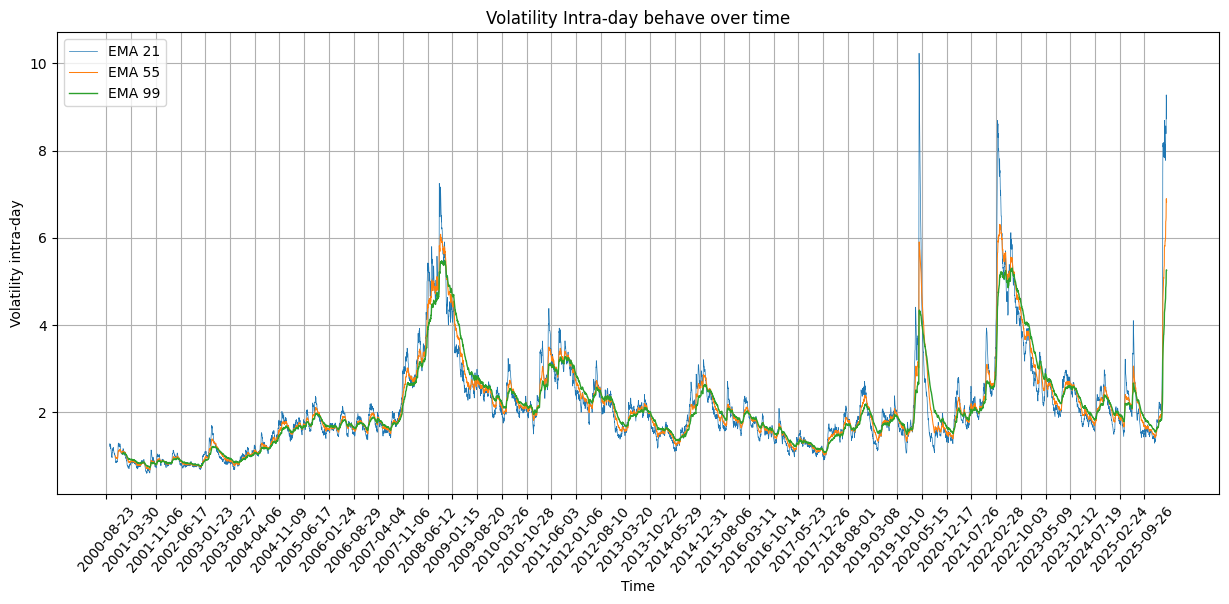

In [20]:
plt.plot(df.index, df.ema21, label='EMA 21', linewidth=0.5)
plt.plot(df.index, df.ema55, label='EMA 55', linewidth=0.75)
plt.plot(df.index, df.ema99, label='EMA 99', linewidth=1)
plt.xlabel('Time')
ax = plt.gca()
ax.set_xticks(df.index[::150]) # Show over 150 periods
plt.xticks(rotation=50)
plt.ylabel('Volatility intra-day')
plt.title('Volatility Intra-day behave over time')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
df.describe()

,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility,sma21,sma55,sma99,adx14,atr14,ema21,ema55,ema99
count,6435.000000,6435.000000,6435.000000,6435.000000,6.435000e+03,6435.000000,6435.000000,6415.000000,6381.000000,6337.000000,6435.000000,6435.000000,6415.000000,6381.000000,6337.000000
mean,64.791389,65.803862,63.709139,64.782224,3.036512e+05,-0.006682,2.094723,2.085889,2.074465,2.073999,23.913510,2.129822,2.086009,2.078759,2.077847
std,24.539134,24.821824,24.230597,24.546185,2.076966e+05,4.888104,1.714188,1.142516,1.016839,0.960830,10.061072,1.137958,1.127095,1.009901,0.941547
min,-14.000000,13.690000,-40.320000,-37.630000,0.000000e+00,-305.970000,0.020000,0.585238,0.709091,0.742121,0.000000,0.000000,0.604197,0.676684,0.730427
25%,46.520000,47.455000,45.610000,46.495000,1.226335e+05,-1.260000,1.200000,1.449524,1.506000,1.543838,16.679658,1.503108,1.462891,1.523584,1.583494
50%,63.810000,64.720000,62.900000,63.800000,2.761160e+05,0.110000,1.730000,1.824762,1.842182,1.876263,21.933948,1.873624,1.835653,1.851066,1.879306
75%,82.005000,83.135000,80.860000,82.095000,3.922305e+05,1.355000,2.510000,2.435238,2.429091,2.393232,29.018942,2.478797,2.429585,2.420720,2.425411
max,145.190000,147.270000,143.220000,145.290000,2.288230e+06,37.660000,58.170000,10.305238,6.828545,6.117273,65.960054,10.452949,10.231834,6.898154,5.483208


In [22]:
df 

,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility,sma21,sma55,sma99,adx14,atr14,ema21,ema55,ema99
Date,,,,,,,,,,,,,,,
2000-08-23,31.95,32.80,31.95,32.05,79385,0.00,0.85,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
2000-08-24,31.90,32.24,31.40,31.63,72978,-1.31,0.84,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
2000-08-25,31.70,32.10,31.32,32.05,44601,1.33,0.78,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
2000-08-28,32.04,32.92,31.86,32.87,46770,2.56,1.06,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
2000-08-29,32.82,33.03,32.56,32.72,49131,-0.46,0.47,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-06,112.96,115.48,108.89,112.41,271742,0.78,6.59,10.276667,5.541818,3.771818,58.494315,8.191943,8.386782,6.387653,4.887509
2026-04-07,112.62,117.63,109.20,112.95,429331,0.48,8.43,9.993810,5.654000,3.840606,58.923461,8.208947,8.390711,6.460594,4.958359
2026-04-08,108.74,109.19,91.05,94.41,599576,-16.41,18.14,9.034286,5.961273,3.995960,55.932583,9.186880,9.277010,6.877715,5.221992


In [23]:
df = df.dropna()

In [24]:
df.describe()

,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility,sma21,sma55,sma99,adx14,atr14,ema21,ema55,ema99
count,6337.00000,6337.000000,6337.000000,6337.000000,6.337000e+03,6337.000000,6337.000000,6337.000000,6337.000000,6337.000000,6337.000000,6337.000000,6337.000000,6337.000000,6337.000000
mean,65.29753,66.317601,64.207256,65.288796,3.073095e+05,-0.006451,2.110346,2.097986,2.081462,2.073999,24.029257,2.146541,2.098275,2.085881,2.077847
std,24.38321,24.661681,24.078798,24.389703,2.071698e+05,4.911977,1.721809,1.144182,1.016876,0.960830,9.961278,1.137440,1.128448,1.009747,0.941547
min,-14.00000,13.690000,-40.320000,-37.630000,0.000000e+00,-305.970000,0.020000,0.585238,0.709091,0.742121,8.260097,0.674794,0.604197,0.676684,0.730427
25%,47.40000,48.360000,46.540000,47.420000,1.285080e+05,-1.260000,1.220000,1.467619,1.515455,1.543838,16.754982,1.521186,1.475596,1.533372,1.583494
50%,64.39000,65.350000,63.390000,64.350000,2.789440e+05,0.110000,1.740000,1.836190,1.846182,1.876263,21.999149,1.889014,1.849156,1.858049,1.879306
75%,82.44000,83.430000,81.190000,82.470000,3.953990e+05,1.350000,2.530000,2.444762,2.438364,2.393232,29.045934,2.488363,2.441498,2.429371,2.425411
max,145.19000,147.270000,143.220000,145.290000,2.288230e+06,37.660000,58.170000,10.305238,6.828545,6.117273,65.960054,10.452949,10.231834,6.898154,5.483208


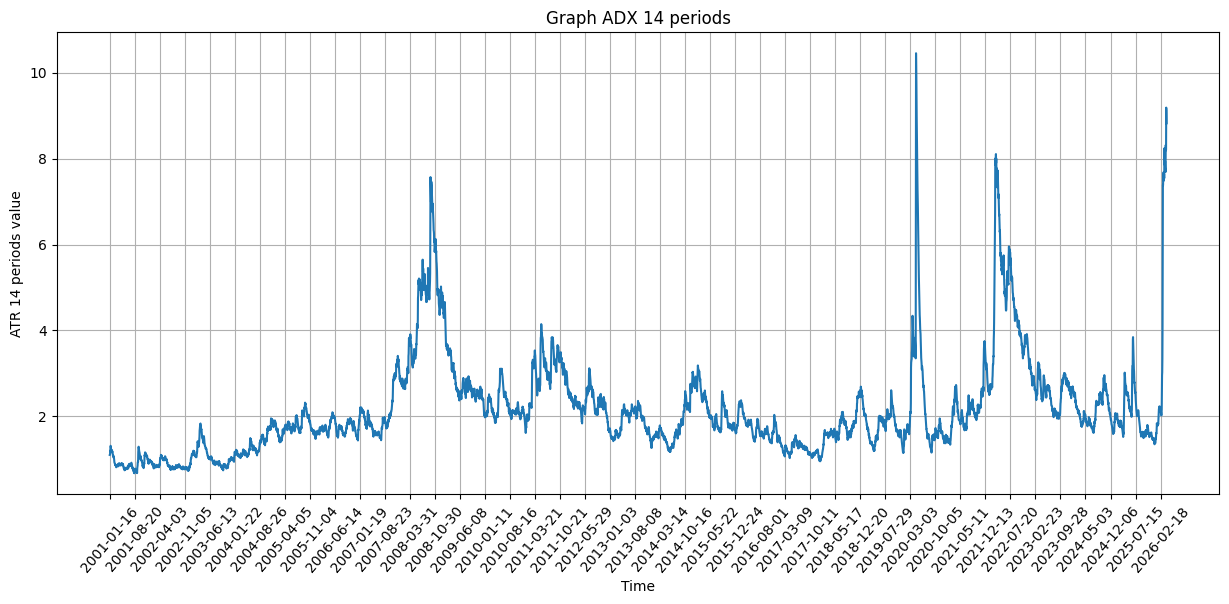

In [25]:
plt.plot(df.index, df.atr14)
plt.xlabel('Time')
plt.ylabel('ATR 14 periods value')
ax = plt.gca()
ax.set_xticks(df.index[::150]) # Show over 150 periods
plt.xticks(rotation=50)
plt.title('Graph ADX 14 periods')
plt.grid(True)
plt.show()

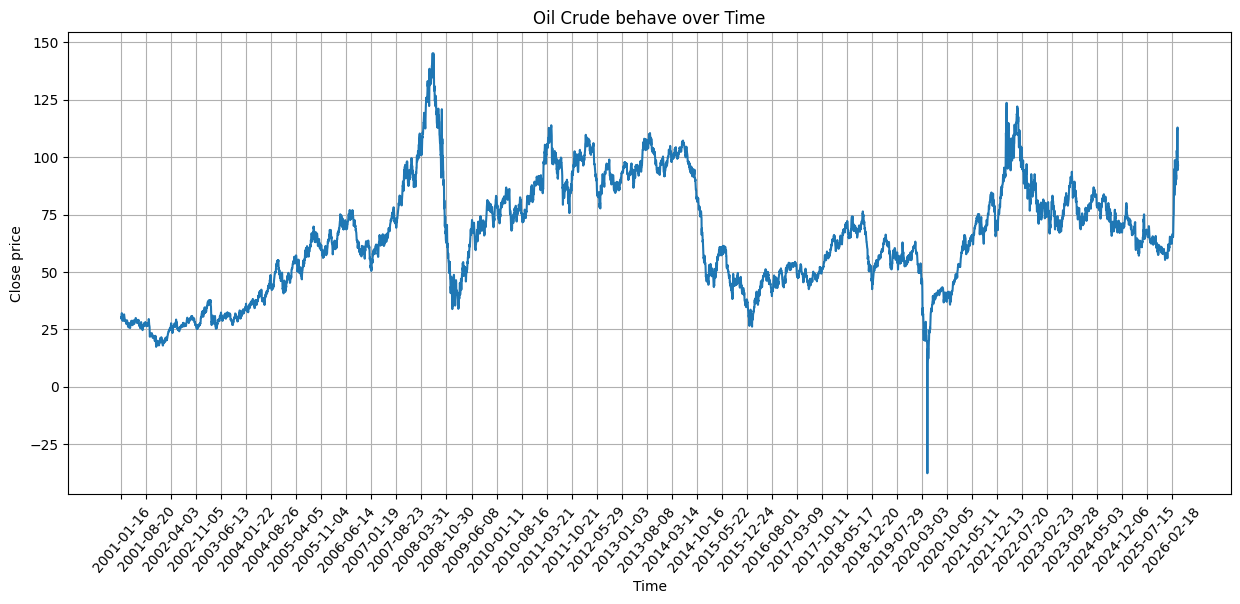

In [26]:
plt.plot(df.index, df.Close, label='Close')
plt.xlabel('Time')
plt.ylabel('Close price')
plt.title('Oil Crude behave over Time')
plt.grid(True)
ax = plt.gca()
ax.set_xticks(df.index[::150]) # Show over 150 periods
plt.xticks(rotation=50)
plt.show()

In [27]:
# Plot a norm distribution
from scipy.stats import norm

In [28]:
X = df.Close

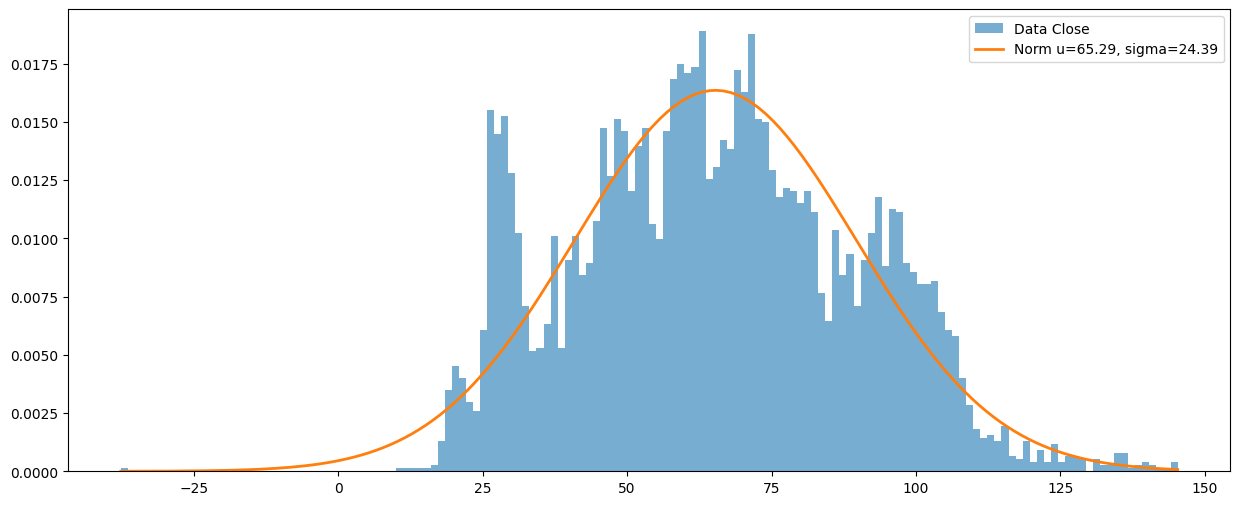

In [30]:
# Norm histogram

plt.hist(X, bins=150, density=True, alpha=0.6, label='Data Close')

# Adjust norm to data

mu, sigma = norm.fit(X)

# Norm curve

xs = np.linspace(X.min(), X.max(), 150)
plt.plot(xs, norm.pdf(xs, mu, sigma), lw=2, label=f'Norm u={mu:.2f}, sigma={sigma:.2f}')

plt.legend()
plt.show()

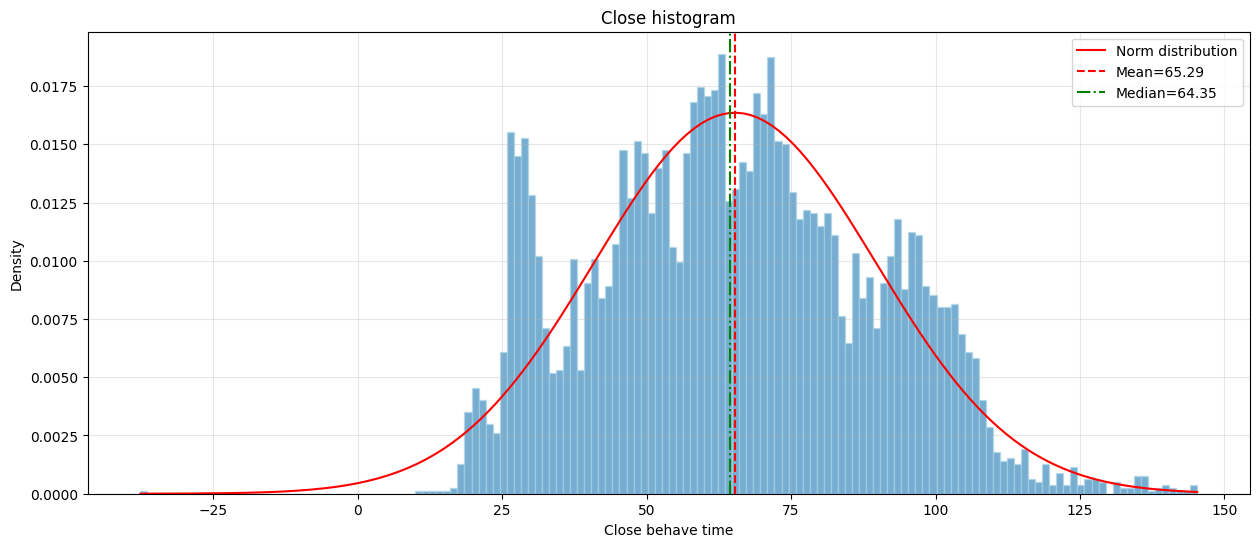

In [32]:
# Plot norm hist

# Calculate Median and Mean

median = X.median()
mean = X.mean()

# Plot a norm histogram

xs = np.linspace(X.min(), X.max(), 150)
plt.hist(X, bins=150, density=True, alpha=0.6, edgecolor='lightblue')
plt.plot(xs, norm.pdf(xs, mu, sigma), color='red', linewidth=1.5, label='Norm distribution')

# Mean

plt.axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean:.2f}')

# Median

plt.axvline(median, color='green', linestyle='-.', linewidth=1.5, label=f'Median={median:.2f}')

plt.xlabel('Close behave time')
plt.ylabel('Density')
plt.title('Close histogram')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

From all indications, the data follow a normal distribution, given the large amount of data collected over the sample period.

In [35]:
from scipy import stats

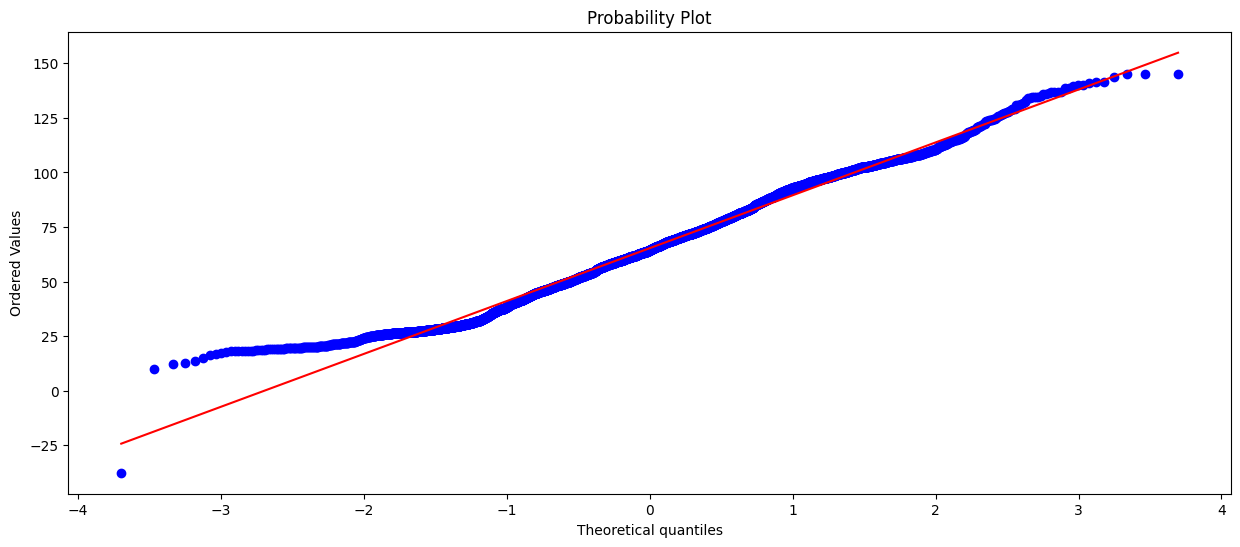

In [36]:
stats.probplot(df.Close, dist='norm', plot=plt)
plt.show()

In [37]:
# Calculate assimetry

from scipy.stats import skew

In [39]:
# Between -0.5 and 0.5: Approximately asymmetrical
# Between 0.5 and 1: Moderately asymetrical
# Above 1: highely asymetrical

print(skew(df.Close))

0.17156586964754456


In [40]:
from scipy.stats import kurtosis

In [41]:
# 0 = norm
# 0 = heavy caude
# < 0 = easy caude

print(kurtosis(df.Close))

-0.4997191927030915


In [43]:
from scipy.stats import normaltest

In [44]:
stat, p = normaltest(df.Close)

In [46]:
print(f'Stat = {stat:.4f}')
print(f'p-value = {p:.4f}')

# There is not norm distribution

Stat = 151.0837
p-value = 0.0000


In [47]:
returns_close = np.log(df.Close).diff().dropna()

c:\Users\Azog\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [48]:
stat, p = normaltest(returns_close)

In [50]:
print(f'Stat returns close = {stat:.4f}')
print(f'p-value returns close = {p:.4f}')

# There is not norm distribution

Stat returns close = 1426.4252
p-value returns close = 0.0000
